In [1]:
import forgethreads as ft
import numpy as np



In [2]:

rng = np.random.default_rng()
ft.set_verbose(False)


In [3]:
# n= 100
# distribution = 0.7

# m_size = n ** 2 



# # Llenar segun distribucion

# m1= np.zeros(shape=(1,n,n))

# total_for_fill =  (n * (n-1)) / 2
# total_for_fill_pondered = total_for_fill * distribution

# ni = 0
# while(ni < total_for_fill_pondered):
#   o = rng.integers(0,n)
#   d = rng.integers(0,n)
#   if(m1[0,o,d]) == 0:
#     m1[0,o,d] = 1
#     m1[0,d,o] = 1
#     ni += 1



# m2 = m1.copy()
# paths,values, max_order = ft.maxmin(m1,m2,0.1,200,False)

In [4]:
def build_matrix(n, m, d, seed=None):
    rng = np.random.default_rng(seed)
    N = n + m
    M = np.zeros((N, N))

    A = rng.uniform(0, 0.5, size=(n, n))
    np.fill_diagonal(A, 1.0)
    M[:n, :n] = A

    D = rng.uniform(0, 0.5, size=(m, m))
    np.fill_diagonal(D, 1.0)
    M[n:, n:] = D

    M[:n, n:] = rng.uniform(0, 0.5, size=(n, m))

    # Máximo de aristas posibles por nodo (nodo en bloque n tiene más conexiones)
    max_degree   = (n - 1) + m
    total_possible = (n**2 - n) + (n * m) + (m**2 - m)

    # Objetivo: d * n aristas en total
    target_edges = int(round(d * n))
    target_edges = min(target_edges, total_possible)  # no puede superar el máximo

    # Celdas modificables con valor < 0.5
    mod = np.zeros((N, N), dtype=bool)
    mod[:n, :n] = True
    mod[:n, n:] = True
    mod[n:, n:] = True
    np.fill_diagonal(mod, False)

    current_edges = int(np.sum(M[mod] > 0.5))
    k_extra = max(0, target_edges - current_edges)

    candidates = np.argwhere(mod & (M < 0.5))
    k_extra = min(k_extra, len(candidates))

    if k_extra > 0:
        chosen = candidates[rng.choice(len(candidates), size=k_extra, replace=False)]
        M[chosen[:, 0], chosen[:, 1]] = rng.uniform(0.5, 1.0, size=k_extra)

    final = int(np.sum(M[mod] > 0.5))
    # print(f"  max_degree={max_degree}, total_posible={total_possible}")
    # print(f"  target={target_edges}, añadidas={k_extra}, final={final}, "
    #       f"densidad_real={final/n:.3f}")
    return M.reshape(1, N, N).astype(np.float16)

In [5]:
def run_experimental(n, avg_degree,i):
    m1 = build_matrix(n,n,avg_degree,1111)
    m2 = m1.copy()
    paths, values, max_order = ft.maxmin_reduced(m1, m2, 0.5, 6,False,avg_degree)
    if i ==0:
      print(paths.to_numpy())
    return max_order

In [ ]:
ns = [10000]
iterations = 1
avg_degrees = []
proms_by_n = []
for n in ns:
    m = n
    max_d = float(n**2 - n + n*m + m**2 - m) / (n + m)

    # avg_degrees = np.array([0.1*max_d, 0.3*max_d, 0.5*max_d, 0.75*max_d], dtype=np.float16)
    
    avg_degrees = np.arange(int(np.log(n)),int(np.log(n)) + 1,step=0.2,dtype=np.float16) 
    print(avg_degrees)
    proms = []
    for deg in avg_degrees:
        acum = 0
        for i in range(iterations):
        
            acum += run_experimental(n, float(deg),i)
        proms.append(acum / iterations)
        print(f"deg={deg} : n={n} ", end="\t")
    print(f"\ncalculated averages for {n} nodes")
    proms_by_n.append(proms)

# p300 = np.load("proms_300n.npy")
# p400 = np.load("proms_400n.npy")
# p500 = np.load("proms_500n.npy")

# proms_by_n.append(p300[0]) E(eta_0) < b log(N), 
# proms_by_n.append(p400[0])
# proms_by_n.append(p500[0])

[9.   9.2  9.41 9.61 9.81]


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_proms(ns, avg_degrees, proms_by_n):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, n in enumerate(ns):
        color = colors[i % len(colors)]
        ax.plot(avg_degrees, proms_by_n[i], 'o-', label=f"N = {n}", 
                linewidth=2, markersize=5, color=color)

    ax.axvline(x=1.0,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(x=10.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xscale('log')
    ax.set_xticks(avg_degrees)
    ax.set_xticklabels([str(d) for d in avg_degrees], rotation=30, fontsize=9)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel("Grado promedio (avg_degree)", fontsize=12)
    ax.set_ylabel("E[η₀] — orden máximo promedio", fontsize=12)
    ax.set_title("Orden máximo promedio vs densidad del grafo", fontsize=13)
    
    # Leyenda combinada: curva + ln(n)
    handles, labels = ax.get_legend_handles_labels()
    for i, n in enumerate(ns):
        color = colors[i % len(colors)]
        handles.append(plt.Line2D([0], [0], color=color, linestyle=':', linewidth=1.5, alpha=0.7))
    
    ax.legend(handles=handles, labels=labels, title="Nodos N", fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
np.save("all_degrees",proms_by_n)

/tmp/ipykernel_1121/2933924214.py:30: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  ax.legend(handles=handles, labels=labels, title="Nodos N", fontsize=10, ncol=2)


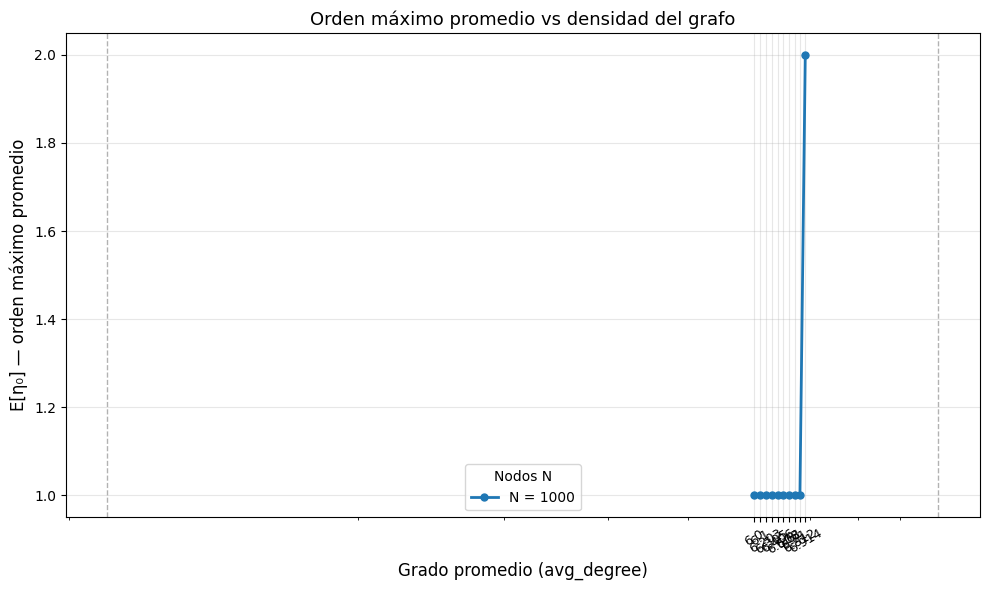

In [ ]:
plot_proms(ns, avg_degrees, proms_by_n)